In [1]:
# Import navis

## Image viewing
import os
from pathlib import Path
import uuid
import math

from scipy.special import expit

from tqdm.auto import tqdm

import navis


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix
import itertools

import pint

import colorcet as cc

# Import neuprint wrapper by navis
import navis.interfaces.neuprint as neu


auth_token = "eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJlbWFpbCI6InZoMjMwOEBueXUuZWR1IiwibGV2ZWwiOiJub2F1dGgiLCJpbWFnZS11cmwiOiJodHRwczovL2xoMy5nb29nbGV1c2VyY29udGVudC5jb20vYS0vQUxWLVVqVzF1TnhSVS1WWHhFWldIVHZIMkhFeXo1cFZCS2RZNUdKdGpqRzd4T19nREtQY3kyWDc4M0s1akJMWHRwU1F2UjYyTGstd3AtTFJfNGpqNDJHSXhVWUYtRURSNVFjVXBKdlZtWV9XNi12b2hTUVAyRnFXVnhxTjdMRDFGNEpYRzdwU3dZRDFFNWFrSHFXN25BaWRmbnh4NE1pQnN2YnQxUU5YYUw2VkVVczRzQnBwMnQ4ZmJmNzJPY2xxY3V6QWVmYTFpcldFOXhHMUVZWWlQSUhfX1VHaF96R0w0aGFNak1iWGdCcUpIcVJsMW5rcVBKenRiaDd3V2lzTWl1czRqZ1JhVlAtU0RyeWpudk9SQ2V1aTFRaW9MbDZvZjB1ZWhEalZZN2hjZXBiVFdzZWktZUJKekxOMHVLVWVtQ2w4Q1NZcEsxSjhuVFdZSFowLS1nUUZOaFFLUHJpalpwc3dwZ1E5TkQ0dFlST0RBRW9GYzMtR1ItTHU1aWRIQjlBd0N2NUxSODNHOW43TU16eWdaS3dnSElQUk1ORl80bkQ4TzM4VV84bnFKeEwxLWxKUk1lYXlXWW05bW1maU5PcXlOZnJyT1IwaDZyVm96RFZmOE9scWRJaG10T1g4blVPeldkQTVVM3E5U1BBRVJMYzJGR1FSRVVtU1E0TFNnY05CZk81cTE5ci04NkxaTWVqd25wNnV1eGhYR2VtNEZsbFBLbk1SZjV2N045alFaVVdLMGo3eHB4YWZwc0dDS0t6SVBMdm5LaWtway1oV2tJUTd4ZFVNN3R6TFR0eG05MFpjcEZJSlY4M1lKTTNNb0Z1ZkNVY3lwLVdFUWttc25najU3dVFQQmI0N1dhTmZqdEd6cEJ5dzZuNjNzSXRkNGR2WjB0eVBoLW5ZeWYtWVpTMDA4VS1KbWg5bFlqT042a0dzdkswQXM2VEIxaFVLZWJ3eVl3aG5wR3ZvUHUyZC0zZDJfTGZMQ05XSXhrQi1VZkQ4ZWxPdld0bXlLaE5XSDZ4OEE5ZEhxQ3RGU1VlVTdHeDdCdERDUHphV0E1TDg4RFFuekF5OHNKSVkwU0kwVk9TNjdzeHQ2WUR1UHBVdFdabHNNUFY3LWJDSm9mUjNKOE1BWGxyMnZ3c0tCa3RSdEd5Yy1uYl9VN0dkejUxRGdxc293dmZvWmh0RXZ3TExLZU9nM3NfRFlNSkhtdWFQU05QUUFLNDlkSEF3dFBHUjQta3BNT0o1ZHB3YXRHcW1qaG1FM1RkWHpzVzh6R1pVTWpqX0I4WG92MEE5MkR4SUZqMzRqR2FlZFV0VUFsZWcxdWduNThhMEZwYnFFQmxxSkl2TGRwN0Q1Mnk2R0N1WDJFcHZJR0JjbGFXVTBXejJRZ2t3REFTc1ZFSm1ScmF2LTFBdGNJblVFVzFFZ0Z0dldmRndKMFBra2cwPXM5Ni1jP3N6PTUwP3N6PTUwIiwiZXhwIjoxOTY0MjMyODUyfQ.2IB-bBQ1iE9PWe2zqD577hzIK2pAf6zCg5ztnbB_UnE"

# client = Client('neuprint.janelia.org', 'manc:v1.2.3', token=auth_token)

client = neu.Client(
    "https://neuprint.janelia.org/",
    token=auth_token,  # use this to instead pass your token directly
    dataset="manc:v1.2.3",
)

# Force PyImageJ to use Conda's Java, ignoring system defaults.
# Must be set BEFORE scyjava/imagej is imported (those trigger JVM startup).
if "CONDA_PREFIX" in os.environ:
    os.environ["JAVA_HOME"] = os.environ["CONDA_PREFIX"]

# Ensure the JVM is started in headless mode from the very first call.
# In a Jupyter kernel the JVM only starts once; if it comes up without the
# right options, the IJ1 legacy layer ends up 'Inactive' and IJ.openImage()
# (which the H5J_Loader_Plugin relies on) silently returns null.
import scyjava
scyjava.config.add_option("-Djava.awt.headless=true")

import imagej

# FIJI_APP = "/home/william-zheng/Downloads/Fiji.app"
# PROJECT_DIR = "/home/william-zheng/Documents/Programming/Python/NeuroInformatics/summer_2026/neuroinfo_fruitfly"
FIJI_APP = "/Users/vuhepola/Desktop/Fiji"
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FISBe_DIR = DATA_DIR / "FISBe"
FlyLight_DIR = DATA_DIR / "FlyLight"
FANC_DIR = DATA_DIR / "FANC"
MANC_DIR = DATA_DIR / "MANC"

print(FIJI_APP)
print(PROJECT_DIR)
print(DATA_DIR)
print(FISBe_DIR)
print(FlyLight_DIR)
print(FANC_DIR)
print(MANC_DIR)

/Users/vuhepola/Desktop/Fiji
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FISBe
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FlyLight
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/FANC
/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfly/data/MANC


In [2]:
# roi = 'LegNp(T1)(L)'
# target='LegNpT1_L'


# instance=".*T1.*",
neuropil_regex  = "T[123]"
side_regex  = "[LR]"
instance_file_name = f"{neuropil_regex}_{side_regex}"
instance_regex =f".*{neuropil_regex}_{side_regex}.*"
# class_ = "motor neuron",
regex=True

print(instance_file_name)
print(instance_regex)

# t1 = neu.fetch_roi(roi)

T[123]_[LR]
.*T[123]_[LR].*


In [3]:
criteria = neu.NeuronCriteria(
    # rois=roi,
    # target=target,
    instance=instance_regex,
    # class_ = "motor neuron",
    regex=True
)

nl, roi_info = neu.fetch_neurons(
    criteria
)
nl['instance'].value_counts()

instance
IN03B060_T2_R    13
IN19A060_T3_R    13
IN03B060_T2_L    13
IN08A036_T1_R    13
IN08A036_T1_L    12
                 ..
IN09B046_T1_L     1
IN03A021_T3_L     1
IN01B008_T3_L     1
IN17A036_T2_L     1
IN12B040_T1_L     1
Name: count, Length: 7614, dtype: int64

In [4]:
print(len(nl['instance'].value_counts()))
print(len(nl['bodyId'].value_counts()))

7614
12671


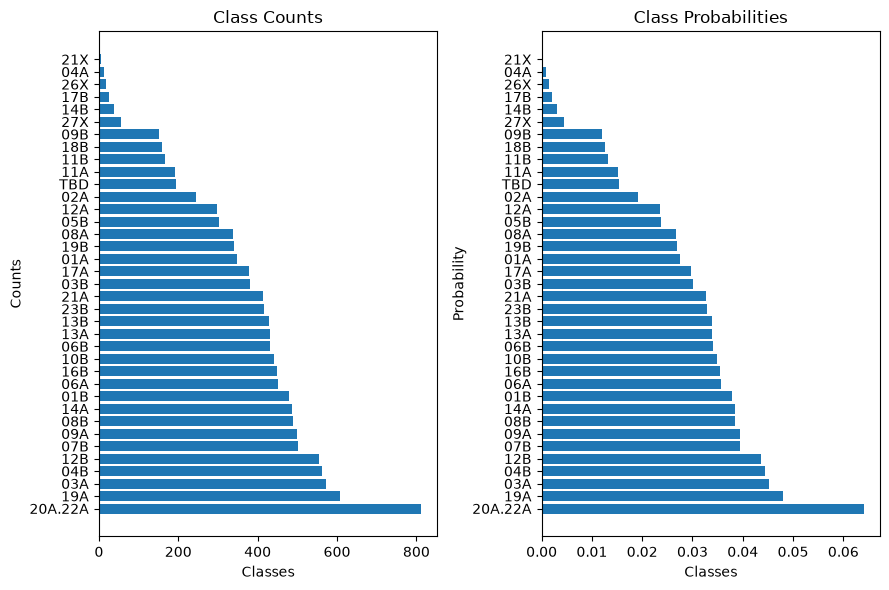

In [5]:
class_counts = nl['hemilineage'].value_counts(dropna=False)
class_probs = nl['hemilineage'].value_counts(dropna=False, normalize=True)

# 1. Correctly initialize figure and axes
fig, axes = plt.subplots(1,2, figsize=(9,6))

axes[0].barh(class_counts.index, class_counts)
axes[0].set_xlabel("Classes")
axes[0].set_ylabel("Counts")
axes[0].set_title("Class Counts")



axes[1].barh(class_probs.index, class_probs)
axes[1].set_xlabel("Classes")
axes[1].set_ylabel("Probability")
axes[1].set_title("Class Probabilities")

# 4. Display the plot

plt.tight_layout()
plt.show()


In [6]:
def write_metadata(neuron_list, skels, output_dir, metadata_file_name="manc_skeletons_metadata.csv"):
    neuron_list_sync = neuron_list.set_index('bodyId').reindex(skels.id).reset_index()

    # Construct the metadata DataFrame
    meta_df = pd.DataFrame({
        'skeleton_id': skels.id, # Using the existing neuron IDs
        'instance_name': skels.name, # Using the existing neuron IDs
        'hemilineage': neuron_list_sync['hemilineage'],
        '_class': neuron_list_sync['class']
    })

    # FIX 2: Save the constructed meta_df directly instead of using .summary()
    meta_df.to_csv(output_dir / metadata_file_name, index=False)

def download_skeletons(x, neuron_list, output_dir, metadata_file_name="manc_skeletons_metadata.csv"):
    
    if len(x)>0:
        print(f"Downloading {len(x)} skeletons")
        skels = neu.fetch_skeletons(x, with_synapses=True)
            
        # Loop through the NeuronList and write each neuron to an SWC file
        for skel in tqdm(skels):
            file_path = os.path.join(output_dir, f"{skel.id}.swc")
            
            print(file_path)
            navis.write_swc(skel, file_path)

        print(f"Successfully saved skeletons to {output_dir}")
        
        write_metadata(neuron_list, skels, output_dir, metadata_file_name)
    else:
        print("No new skeletons")


In [7]:
saved_swc_files = [int(file.stem) for file in (MANC_DIR / "Skeletons").glob("*.swc")]
len(saved_swc_files)

12671

In [8]:
new_ids = nl[~(nl['bodyId'].isin(saved_swc_files))]

len(new_ids)

0

'manc_skeletons_metadata_T[123]_[LR].csv'

In [ ]:

MANC_SKEL_DIR = MANC_DIR / 'Skeletons'
# os.makedirs(MANC_SKEL_DIR, exist_ok=True)

metadata_file_name = f"manc_skeletons_metadata_{instance_file_name}.csv"

download_skeletons(
    x = new_ids,
    neuron_list = nl,
    output_dir = MANC_SKEL_DIR,
    metadata_file_name = metadata_file_name
    )

No new skeletons


In [ ]:
skels = navis.read_swc(MANC_DIR / "Skeletons" / "*.swc")

Importing:   0%|          | 0/12671 [00:00<?, ?it/s]

Dividing:   0%|          | 0/12671 [00:00<?, ?it/s]

In [30]:
skels.id = skels.id.astype(int)

skels_um = skels/(1000/8)
skels_um.id = skels_um.id.astype(int)

Dividing:   0%|          | 0/12671 [00:00<?, ?it/s]

In [31]:
write_metadata(
    neuron_list= nl,
    skels=skels,
    output_dir=MANC_SKEL_DIR,
    metadata_file_name=metadata_file_name,
    )

In [32]:
skels_um

,type,name,id,n_nodes,n_connectors,n_branches,n_leafs,cable_length,soma,units,created_at,origin,file
0,navis.TreeNeuron,23106,23106,1729,None,90,91,1252.477905,3.0,1.0 micrometer,2026-07-22 00:24:34.788692,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,23106.swc
1,navis.TreeNeuron,22218,22218,2987,None,209,216,2213.046875,1849.0,1.0 micrometer,2026-07-22 00:24:34.787810,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,22218.swc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12669,navis.TreeNeuron,22201,22201,2134,None,180,185,1626.841309,1069.0,1.0 micrometer,2026-07-22 00:24:49.866598,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,22201.swc
12670,navis.TreeNeuron,138211,138211,2112,None,415,426,630.081970,NaN,1.0 micrometer,2026-07-22 00:24:49.867510,/Users/vuhepola/GitHub/Repos/neuroinfo_fruitfl...,138211.swc


In [34]:
skels_um.id.dtype == nl['bodyId'].dtype

True

In [35]:
nl_sync = nl[nl['bodyId'].isin(skels_um.id)].copy()
nl_sync = nl_sync.set_index('bodyId').reindex(skels_um.id).reset_index()
nl_sync

,bodyId,instance,type,pre,post,downstream,upstream,size,status,statusLabel,...,cluster,source,subclassabbr,serialMotif,subcluster,locationType,totalNtPredictions,avgLocation,inputRois,outputRois
0,23106,IN06A102_T1_R,IN06A102,216,374,1491,374,390082299,Traced,Roughly traced,...,None,None,None,None,NaN,user,216,"[30022, 35041, 46840]","[HTct(UTct-T3)(L), IntTct, LTct, LegNp(T1)(R),...","[HTct(UTct-T3)(L), IntTct, NTct(UTct-T1)(L)]"
1,22218,IN16B074_T2_R,IN16B074,343,1399,2368,1399,536438945,Traced,Roughly traced,...,None,None,None,independent leg,NaN,user,343,"[32957, 36873, 38454]","[LegNp(T2)(R), Ov(R)]","[LegNp(T2)(R), Ov(R)]"
2,14972,INXXX235_T3_L,INXXX235,371,3298,2530,3298,974098027,Traced,Roughly traced,...,None,None,None,None,NaN,soma,371,None,"[ANm, HTct(UTct-T3)(L), HTct(UTct-T3)(R), LegN...","[ANm, HTct(UTct-T3)(L), HTct(UTct-T3)(R), LegN..."
3,21711,IN16B077_T2_R,IN16B077,257,1242,1676,1242,477385569,Traced,Roughly traced,...,None,None,None,independent leg,13427.0,soma,257,None,"[LegNp(T2)(R), Ov(R)]",[LegNp(T2)(R)]
4,18190,IN03A064_T3_L,IN03A064,548,1237,3107,1237,693408144,Traced,Roughly traced,...,None,None,None,None,NaN,user,548,"[22240, 15488, 16961]","[ANm, LegNp(T3)(L)]","[ANm, LegNp(T3)(L)]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12666,20416,IN04B087_T2_R,IN04B087,660,1178,4903,1178,651963631,Traced,Roughly traced,...,None,None,None,None,NaN,user,660,"[25941, 40027, 29137]","[LegNp(T2)(R), WTct(UTct-T2)(R)]",[LegNp(T2)(R)]
12667,19297,IN09A038_T1_L,IN09A038,265,915,1384,915,604878890,Traced,Roughly traced,...,None,None,None,None,NaN,user,265,"[18951, 36576, 57782]","[LegNp(T1)(L), mVAC(T1)(L)]","[LegNp(T1)(L), mVAC(T1)(L)]"
12668,21708,AN07B082_T1_R,AN07B082,271,364,1702,364,477182177,Traced,Roughly traced,...,None,None,None,None,NaN,user,271,"[26128, 38807, 55528]","[CV, IntTct, LTct, LegNp(T1)(L), LegNp(T1)(R),...","[CV, IntTct, LTct, LegNp(T1)(L), LegNp(T1)(R),..."
12669,22201,IN01B023_T1_L,IN01B023,412,1136,3298,1136,628290728,Traced,Roughly traced,...,None,None,None,independent leg,NaN,soma,412,None,[LegNp(T1)(L)],[LegNp(T1)(L)]


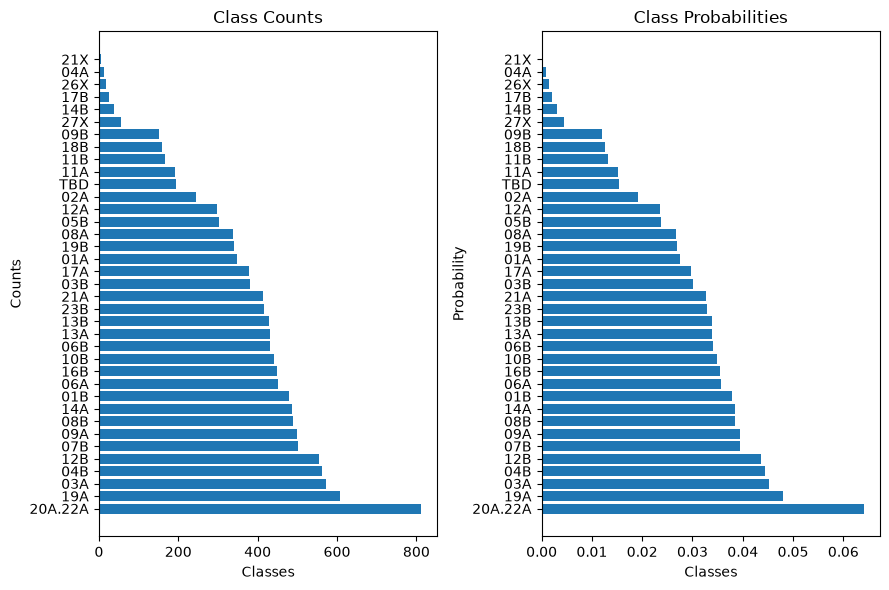

In [36]:
class_counts = nl_sync['hemilineage'].value_counts(dropna=False)
class_probs = nl_sync['hemilineage'].value_counts(dropna=False, normalize=True)

# 1. Correctly initialize figure and axes
fig, axes = plt.subplots(1,2, figsize=(9,6))

axes[0].barh(class_counts.index, class_counts)
axes[0].set_xlabel("Classes")
axes[0].set_ylabel("Counts")
axes[0].set_title("Class Counts")



axes[1].barh(class_probs.index, class_probs)
axes[1].set_xlabel("Classes")
axes[1].set_ylabel("Probability")
axes[1].set_title("Class Probabilities")

# 4. Display the plot

plt.tight_layout()
plt.show()


In [37]:
navis.plot3d(skels_um[:10])

INFO  : Using "plotly" backend for 3D plotting. (navis)


## NBLAST


In [38]:
# Assuming 'scores' is your NBLAST result DataFrame
# Rows = Queries, Columns = Targets

def get_top_n_matches(nblast_scores, n=5):
    """
    Returns a DataFrame showing the top N matches for each query.
    """
    # Get the indices of the top N columns for each row
    # axis=1 sorts across columns
    top_indices = np.argsort(nblast_scores.values, axis=1)[:, ::-1][:, :n]
    
    # Create a new DataFrame for results
    top_matches = pd.DataFrame(index=nblast_scores.index)
    
    for i in range(n):
        # Add the Target ID
        top_matches[f'rank_{i+1}_id'] = nblast_scores.columns[top_indices[:, i]]
        # Add the corresponding NBLAST score
        top_matches[f'rank_{i+1}_score'] = nblast_scores.values[np.arange(nblast_scores.shape[0]), top_indices[:, i]]
        
        # print(f"rank_{i+1}")
        
    return top_matches

def get_k_colors(k, cmap_name='hsv'):
    # Fetch the colormap object
    cmap = plt.colormaps[cmap_name]
    
    # Linearly space k points between 0.0 and 1.0
    colors = [cmap(i) for i in np.linspace(0, 1, k)]
    return colors

def confidence_weighted_vote(predictions, confidences):
    """
    Computes the winning class based on confidence weights.
    
    predictions: list/array of predicted class labels (e.g., [0, 1, 0])
    confidences: list/array of confidence scores for each prediction (e.g., [0.9, 0.4, 0.3])
    """
    # Find all unique class labels present in the votes
    unique_classes = np.unique(predictions)
    
    best_class = None
    max_weighted_vote = -np.inf
    
    # Calculate total weight for each class
    for cls in unique_classes:
        # Sum confidences where the prediction matches the current class
        class_weight = np.sum(confidences[predictions == cls])
        
        if class_weight > max_weighted_vote:
            max_weighted_vote = class_weight
            best_class = cls
            
    return best_class, max_weighted_vote

def top_k_infer_lineage_fast(score_matrix, id_to_class, k=1, verbose=False):
    # print(f"k={k}")
    # Get top matches
    top_k = get_top_n_matches(score_matrix, n=k+1)
        
    # =========================================================
    # OPTIMIZATION 2: Vectorize the 'actual' class lookups 
    # =========================================================
    # Use a lambda function to explicitly enforce the "Unknown" fallback
    actual_lineage_list = top_k['rank_1_id'].map(
        lambda x: id_to_class.get(int(x), "Unknown")
    ).astype(str).values
    
    # print(actual_lineage_list)
    
    # =========================================================
    # OPTIMIZATION 3: Extract prediction matrices all at once
    # =========================================================
    id_cols = [f'rank_{i}_id' for i in range(2, k+2)]
    score_cols = [f'rank_{i}_score' for i in range(2, k+2)]
    
    # FIX: The lambda guarantees no None/NaN values are generated
    # .astype(str) acts as a final safeguard to ensure the matrix is 100% strings
    classes_matrix = top_k[id_cols].map(
        lambda x: id_to_class.get(int(x), "Unknown")
    ).astype(str).values
    
    scores_matrix = top_k[score_cols].values
    
    # =========================================================
    # OPTIMIZATION 4: Fast row-iteration with zip
    # =========================================================
    predicted_lineage_list = []
    max_score_list = []
    max_weighted_vote_list = []
    
    for c_row, s_row in zip(classes_matrix, scores_matrix):
        predicted_class, max_weighted_vote = confidence_weighted_vote(c_row, s_row)
        predicted_lineage_list.append(predicted_class)
        max_score_list.append(s_row[0].item())
        max_weighted_vote_list.append(max_weighted_vote)
        
    # print(max_score_list)
        
    return actual_lineage_list, np.array(predicted_lineage_list), max_score_list, max_weighted_vote_list

In [39]:
def evaluate_and_plot_knn(matrix_dict, id_to_class, k_values=range(1, 5)):
    """
    Evaluates K-Votes lineage classification accuracy across multiple preprocessed matrices
    and plots a 2x2 performance grid.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True, sharex=True)
    axes = axes.flatten()
    
    for i, (title, matrix) in enumerate(matrix_dict.items()):
        accuracy_list = []
        
        for k in tqdm(k_values, desc=f"Tuning {title}"):
            # Pass BOTH sorted_target_neurons and id_to_class down to your infer function
            actual, predicted, _, _ = top_k_infer_lineage_fast(
                matrix, 
                id_to_class=id_to_class, # <-- Added this!
                k=k
            )
            # print(predicted)
            correct_count = sum(1 for act, pred in zip(actual, predicted) if act == pred and pred is not None)
            accuracy = (correct_count / len(actual)) * 100
            accuracy_list.append(accuracy)
            
        best_idx = np.argmax(accuracy_list)
        best_k = list(k_values)[best_idx]
        best_score = accuracy_list[best_idx]
        
        print(f"{title} -> Best k = {best_k}, Accuracy: {best_score:.2f}%")
        
        # Plot coordinates
        axes[i].plot(k_values, accuracy_list, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=7)
        axes[i].plot(best_k, best_score, marker='*', color='#d62728', markersize=14, label='Peak Accuracy' if i == 0 else "")
        
        # Styling
        axes[i].set_title(title, fontsize=14, fontweight='bold', pad=10)
        axes[i].set_xlabel("k (Nearest Neighbors)", fontsize=11, labelpad=8)
        axes[i].set_ylabel("Classification Accuracy (%)", fontsize=11, labelpad=8)
        axes[i].set_xticks(list(k_values))
        axes[i].grid(True, linestyle='--', alpha=0.5)
        
        if i == 0:
            axes[i].legend(loc='lower right', frameon=True)
            
    for ax in axes:
        ax.label_outer()
        
    fig.suptitle("KNN Lineage Classification Accuracy across NBLAST Preprocessing Variations", 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

In [40]:
dps = navis.make_dotprops(skels_um)

Dotprops:   0%|          | 0/12671 [00:00<?, ?it/s]

In [42]:
navis.plot3d(dps[:10])

In [45]:
perform_NBLAST = False

try:
    raw_score_matrix = pd.read_parquet(MANC_DIR / 'Skeletons' / f'{instance_file_name}_raw_nblast_scores.parquet')
except:
    print(f"No stored NBLAST for {instance_file_name}.")
    if perform_NBLAST:
        raw_score_matrix = navis.nblast_allbyall(dps, n_cores=4, normalized=False)
        raw_score_matrix.to_parquet(MANC_DIR / 'Skeletons' / f'{instance_file_name}_raw_nblast_scores.parquet')

No stored NBLAST for T[123]_[LR].


In [ ]:
raw_score_matrix

#### self-match normalization


In [ ]:
score_matrix_self_normalized = raw_score_matrix.div(np.diag(raw_score_matrix), axis=0)

#### row-wise z-scoring


In [ ]:
score_matrix_row_standardized = (raw_score_matrix.sub(raw_score_matrix.mean(axis=1), axis=0)).div(raw_score_matrix.std(axis=1), axis=0)

#### global z-scoring


In [ ]:
score_matrix_global_standardized = (raw_score_matrix - raw_score_matrix.to_numpy().mean()) / raw_score_matrix.to_numpy().std()

In [ ]:
matrix_dict = {
    "Raw": raw_score_matrix,
    "Self-Match Normalized": score_matrix_self_normalized,
    "Row Standardized": score_matrix_row_standardized,
    "Global Standardized": score_matrix_global_standardized,
    }

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, (title, m) in enumerate(matrix_dict.items()):

    sns.heatmap(m,ax=axes[i],
        cmap="viridis",
    )
    
    axes[i].set_title(title)
    axes[i].set(xlabel="target", ylabel="query", xticklabels="", yticklabels="")

fig.suptitle("All-by-All Forward NBLAST score heatmaps")

plt.tight_layout()
plt.show()

## All-pairs Mean NBLAST


In [ ]:
raw_score_matrix_mean = (raw_score_matrix + raw_score_matrix.T)/2
score_matrix_self_normalized_mean = (score_matrix_self_normalized + score_matrix_self_normalized.T)/2
score_matrix_row_standardized_mean = (score_matrix_row_standardized + score_matrix_row_standardized.T)/2
score_matrix_global_standardized_mean = (score_matrix_global_standardized + score_matrix_global_standardized.T)/2

In [ ]:
mean_matrix_dict = {
    "Raw": raw_score_matrix_mean,
    "Self-Match Normalized": score_matrix_self_normalized_mean,
    "Row Standardized": score_matrix_row_standardized_mean,
    "Global Standardized": score_matrix_global_standardized_mean
    }

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, (title, m) in enumerate(mean_matrix_dict.items()):

    sns.heatmap(m,ax=axes[i],
        cmap="viridis",
    )
    
    axes[i].set_title(title)
    axes[i].set(xlabel="target", ylabel="query", xticklabels="", yticklabels="")
    
fig.suptitle("All-by-All Bidirectional Mean NBLAST score heatmaps")

plt.tight_layout()
plt.show()

## Infer


In [ ]:
id_to_class = dict(zip(nl_sync['bodyId'],nl_sync['hemilineage']))

In [ ]:
def get_neuron_from_dp_id(dp_ids, skels_um, dps):
    
    # print(dp_ids)
    
    neuron_list = []
    for dp_id in dp_ids:
        
        temp_skel = skels_um[skels_um.id == int(dp_id)]
        # print(temp_skel)
        neuron_list.append(temp_skel)
    
    return navis.NeuronList(neuron_list)

def display_matches(score_matrix, q_id, skels_um, dps,  k = 1):

    # print(q_id)
    
    neurons_to_show = []

    m = get_neuron_from_dp_id(
        dp_ids = [q_id],
        skels_um=skels_um,
        dps = dps,
        )

    neurons_to_show.extend(m)


    next_best_matches = score_matrix.loc[q_id].nlargest(k+1)
    print(next_best_matches)

    best_ids = next_best_matches.index[1:k+1]
    
    # print(len(best_ids))

    n = get_neuron_from_dp_id(
        dp_ids = best_ids,
        skels_um=skels_um,
        dps = dps,
        )

    # print(len(n))
    neurons_to_show.extend(n)

    # neurons_to_show = navis.NeuronList(neurons_to_show)
    
    navis.plot2d(neurons_to_show)
    
    # print()
        
        
q_ids = raw_score_matrix_mean.index[:10]
# print(q_id)

for q_id in q_ids:
    print()
    display_matches(
        score_matrix = raw_score_matrix_mean,
        q_id = q_id,
        skels_um = skels_um,
        dps = dps, 
        k = 0
        )
    display_matches(
        score_matrix = raw_score_matrix_mean,
        q_id = q_id,
        skels_um = skels_um,
        dps = dps, 
        k = 3
        )

In [ ]:
evaluate_and_plot_knn(matrix_dict, id_to_class, k_values=range(1, 20))

In [ ]:
evaluate_and_plot_knn(mean_matrix_dict, id_to_class, k_values=range(1, 20))